In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path
from glob import glob
import re
import warnings
from matplotlib.lines import Line2D
warnings.filterwarnings('ignore')

# Paper-quality plot settings
plt.rcParams.update({
    'font.size': 16,
    'axes.labelsize': 16,
    'axes.titlesize': 16,
    'legend.fontsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'figure.figsize': (8, 8),
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'lines.linewidth': 2,
    'axes.grid': False,
    'grid.alpha': 0.3,
    'font.family': 'arial',
    'legend.frameon': False
})

# Output directory for plots
PLOT_DIR = Path('plots/cifar10_rmsProp/')
PLOT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Plots will be saved to: {PLOT_DIR.absolute()}")

Plots will be saved to: /Users/sambt/iaifi/sv3/claude_experiments/plots/cifar10_rmsProp


In [2]:
# Load all experiment results and combine into single DataFrame
RESULTS_DIR = Path('../experiment_results/cifar10_scan/')

all_dfs = []
file_pattern = '*.pkl'

for filepath in sorted(RESULTS_DIR.glob(file_pattern)):
    # Extract batch_size and width from filename
    match = re.search(r'bs(\d+)_width(\d+)', filepath.name)
    if match:
        bs_from_name = int(match.group(1))
        width_from_name = int(match.group(2))
        
        with open(filepath, 'rb') as f:
            df_temp = pickle.load(f)
        
        # Ensure batch_size and mlp_width columns exist
        if 'batch_size' not in df_temp.columns:
            df_temp['batch_size'] = bs_from_name
        if 'mlp_width' not in df_temp.columns:
            df_temp['mlp_width'] = width_from_name
            
        all_dfs.append(df_temp)
        #print(f"Loaded {filepath.name}: {len(df_temp)} rows")

df = pd.concat(all_dfs, ignore_index=True)
print(f"\nTotal: {len(df)} experiment runs")
print(f"\nColumns: {df.columns.tolist()}")


Total: 30 experiment runs

Columns: ['batch_size', 'k_fraction', 'k', 'lr', 'rtol', 'resnet_width', 'losses', 'svd_info', 'svd_mode', 'rmsProp', 'alpha_rmsProp', 'optimizer', 'mlp_width']


In [3]:
# Helper functions
def get_final_loss(row, loss_type='val'):
    """Get final epoch loss."""
    return row['losses'][loss_type][-1]

def get_final_acc(row, acc_type='val_acc'):
    """Get final epoch accuracy."""
    if acc_type in row['losses']:
        return row['losses'][acc_type][-1]
    return np.nan

def get_best_acc(row, acc_type='val_acc'):
    """Get best epoch accuracy."""
    if acc_type in row['losses']:
        return max(row['losses'][acc_type])
    return np.nan

def get_best_loss(row, loss_type='val'):
    """Get best epoch loss."""
    return min(row['losses'][loss_type])

def get_loss_curve(row, loss_type='val'):
    """Get per-epoch loss curve."""
    return np.array(row['losses'][loss_type])

def get_acc_curve(row, acc_type='val_acc'):
    """Get per-epoch accuracy curve."""
    if acc_type in row['losses']:
        return np.array(row['losses'][acc_type])
    return None

def get_svd_info(row):
    """Get SVD singular values and counts."""
    if row['svd_info'] is None or (isinstance(row['svd_info'], float) and pd.isna(row['svd_info'])):
        return None, None
    return row['svd_info'].get('svs'), row['svd_info'].get('num_nonzero_svs')

def sliding_average(data, window=10):
    """Compute sliding average for smoothing."""
    return np.convolve(data, np.ones(window)/window, mode='valid')

# Add derived columns
df['final_val_loss'] = df.apply(lambda r: get_final_loss(r, 'val'), axis=1)
df['final_train_loss'] = df.apply(lambda r: get_final_loss(r, 'train'), axis=1)
df['final_val_acc'] = df.apply(lambda r: get_final_acc(r, 'val_acc'), axis=1)
df['final_train_acc'] = df.apply(lambda r: get_final_acc(r, 'train_acc'), axis=1)
df['best_val_acc'] = df.apply(lambda r: get_best_acc(r, 'val_acc'), axis=1)
df['best_train_acc'] = df.apply(lambda r: get_best_acc(r, 'train_acc'), axis=1)
df['best_val_loss'] = df.apply(lambda r: get_best_loss(r, 'val'), axis=1)

In [5]:
# Separate SVD and baseline results
df_svd = df[df['optimizer'] == 'SVD'].copy()
df_baseline = df[df['optimizer'] != 'SVD'].copy()

# get only the ones with rmsProp on for svd
df_svd = df_svd[(df_svd['rmsProp'] == True)]

# Extract unique hyperparameters
batch_sizes = sorted(df['batch_size'].unique())
mlp_widths = sorted(df['mlp_width'].unique())
k_values = sorted(df_svd['k'].dropna().unique())
svd_lrs = sorted(df_svd['lr'].unique())
baseline_lrs = sorted(df_baseline['lr'].unique())
baseline_optimizers = df_baseline['optimizer'].unique().tolist()
rtols = sorted(df_svd['rtol'].dropna().unique())
optimizers_baseline = df_baseline['optimizer'].unique().tolist()

print("SVD Hyperparameters:")
print(f"  k_values: {k_values}")
print(f"  Learning rates: {svd_lrs}")
print(f"\nBaseline Hyperparameters:")
print(f"  Optimizers: {baseline_optimizers}")
print(f"  Learning rates: {baseline_lrs}")
print(f"\nMLP Widths: {mlp_widths}")
print(f"Batch Sizes: {batch_sizes}")
print(f"Rtol values: {rtols}")
print("Baseline optimizers:", optimizers_baseline)

SVD Hyperparameters:
  k_values: [8, 16]
  Learning rates: [1.0, 10.0, 50.0, 100.0]

Baseline Hyperparameters:
  Optimizers: []
  Learning rates: []

MLP Widths: [6]
Batch Sizes: [32, 64]
Rtol values: [0.001, 0.01, 0.1]
Baseline optimizers: []


## compare learning curves at different k, fix bs / rtol / lr

### train loss

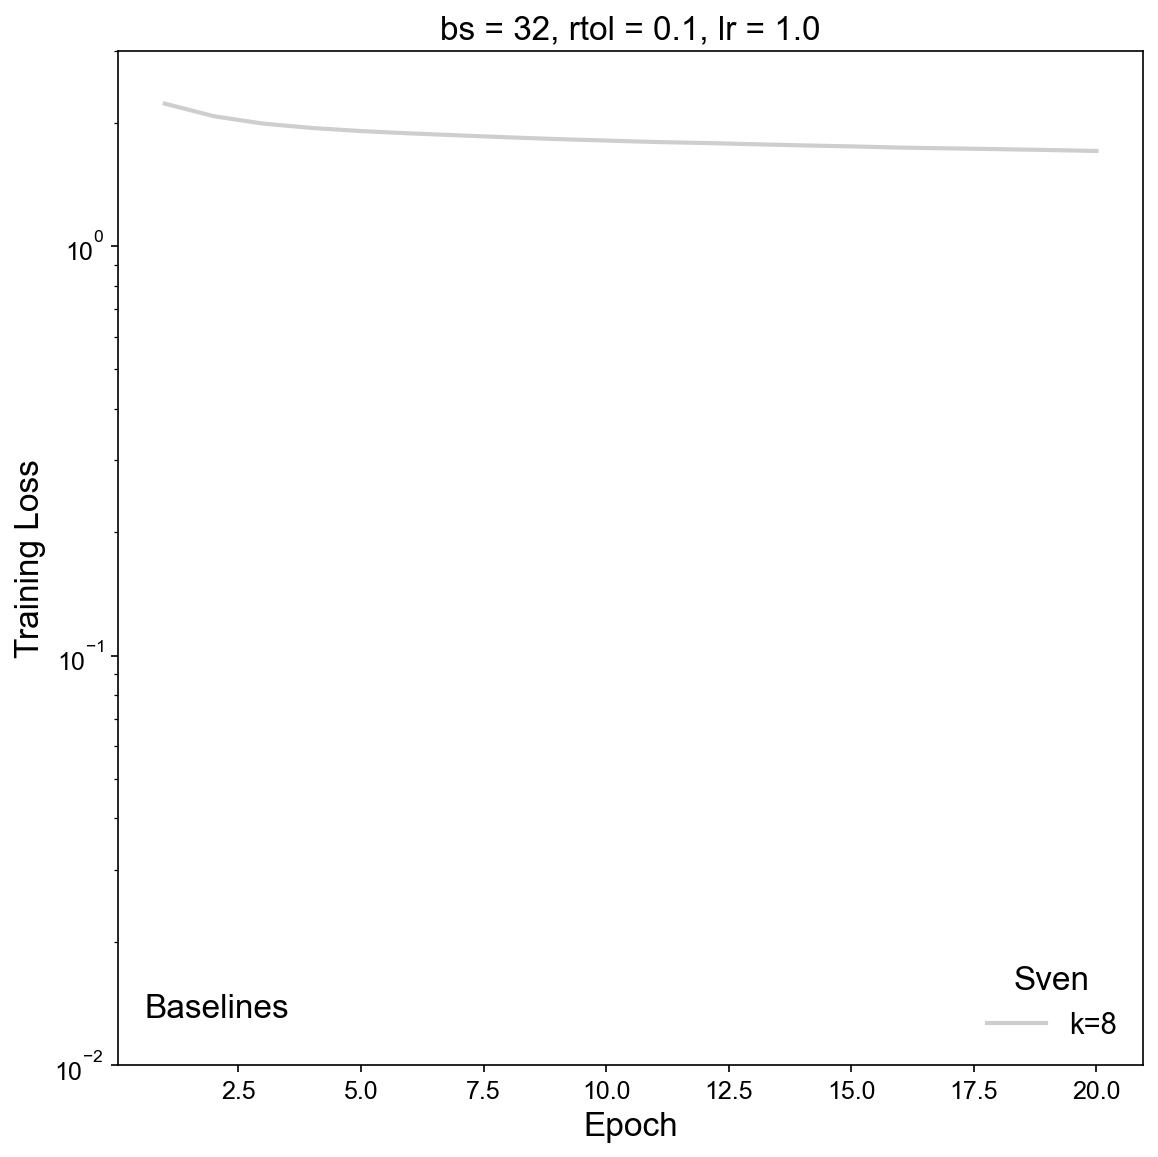

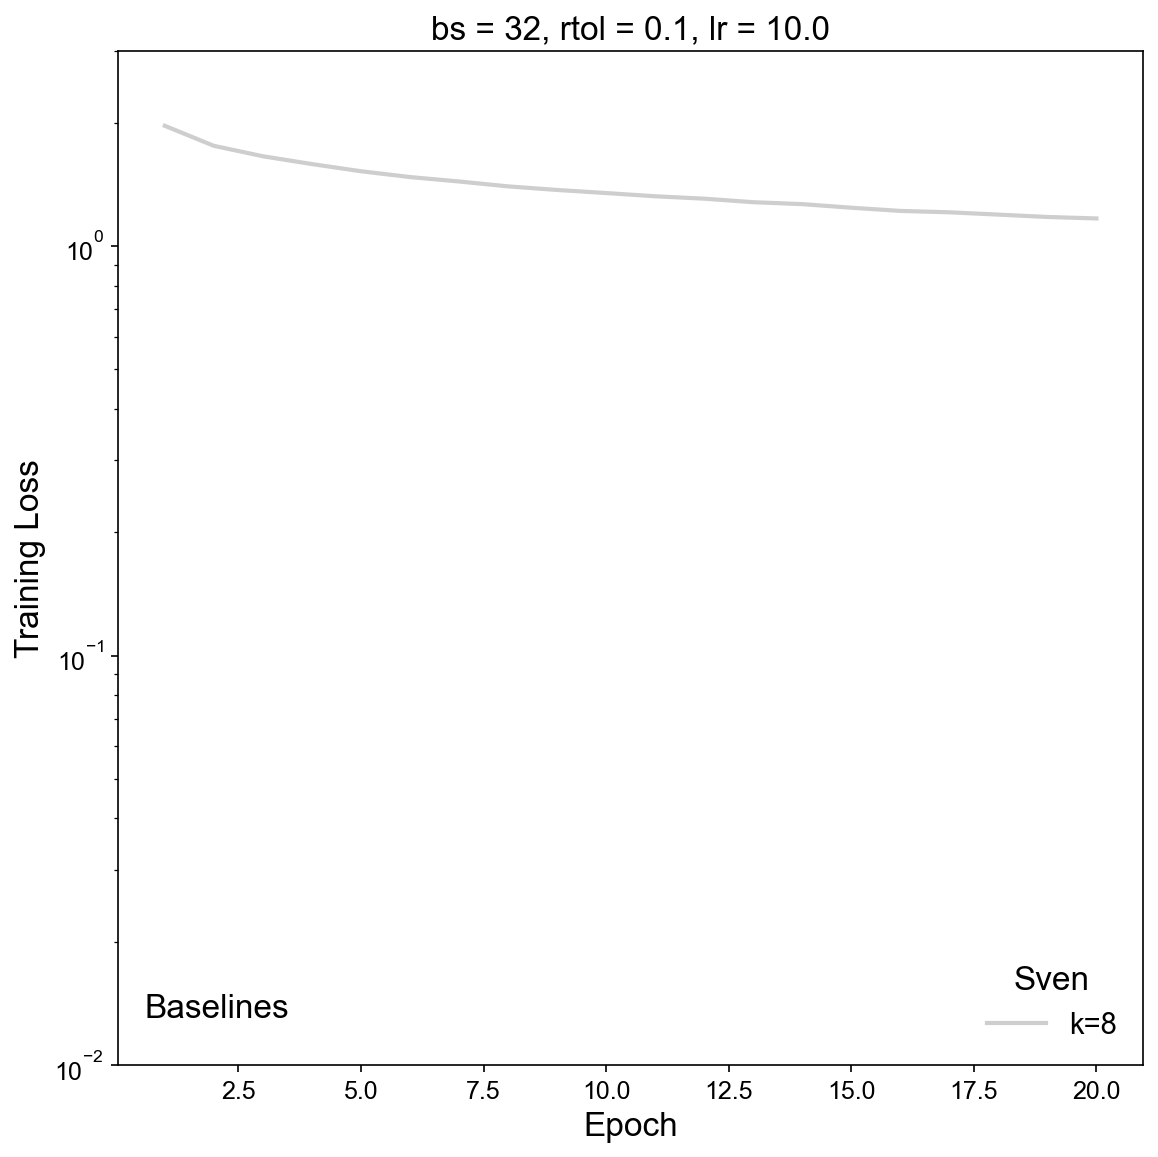

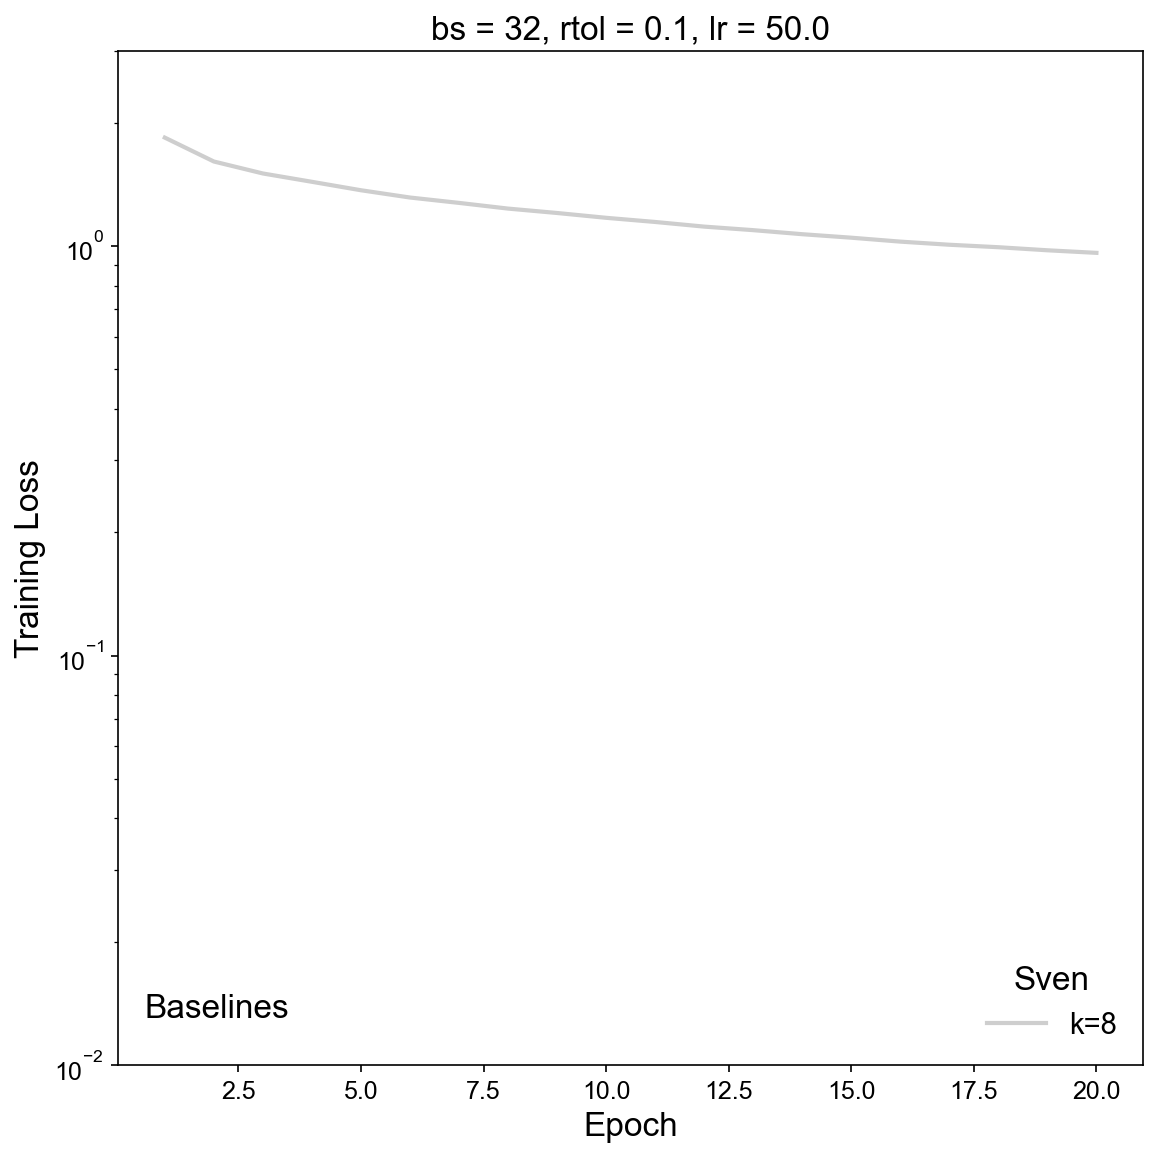

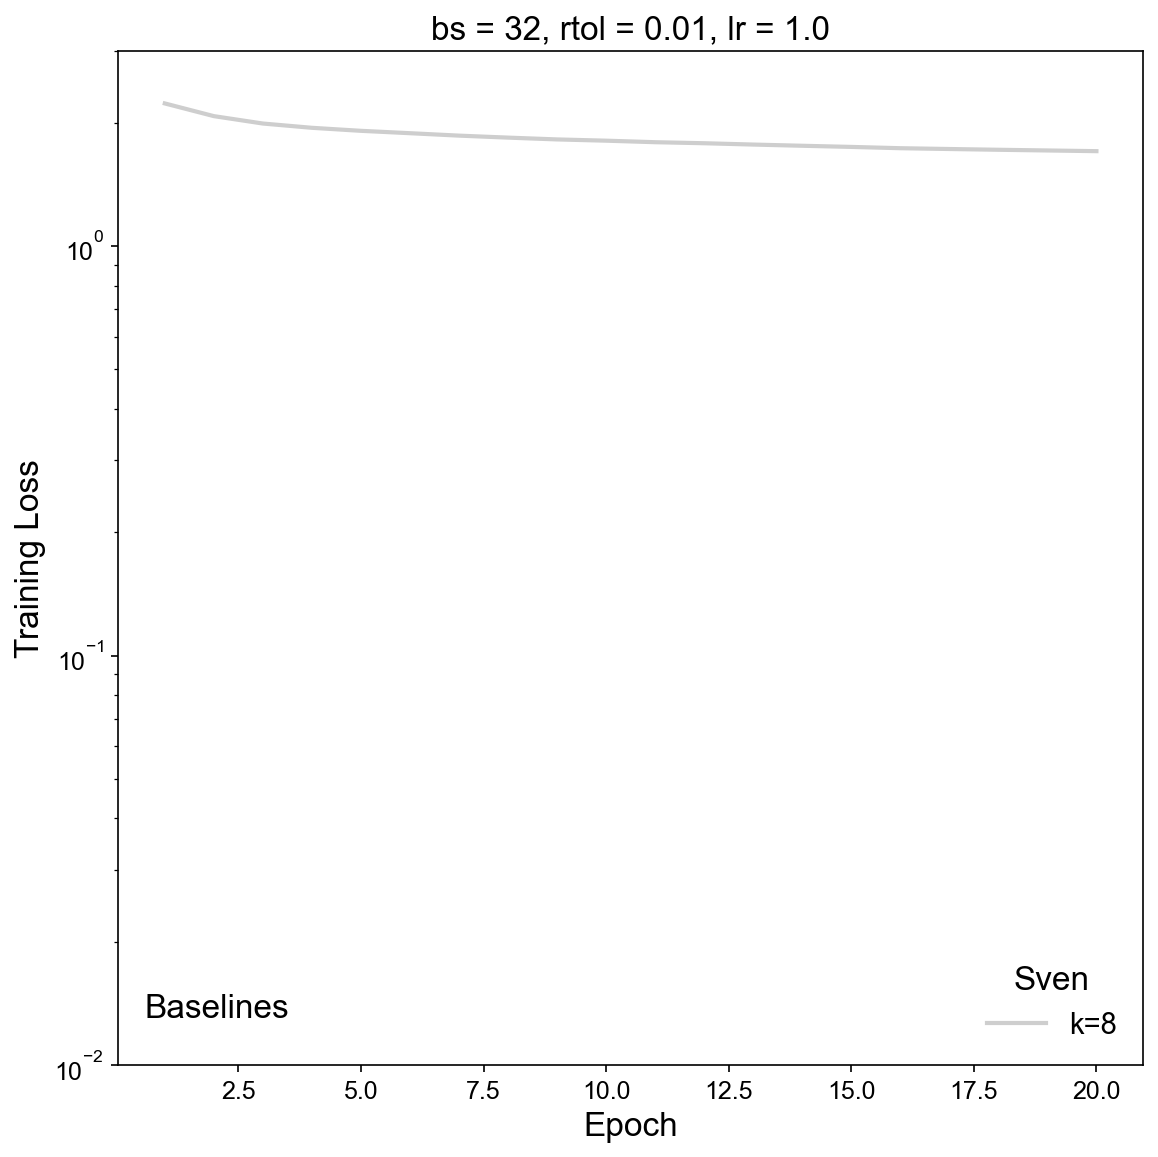

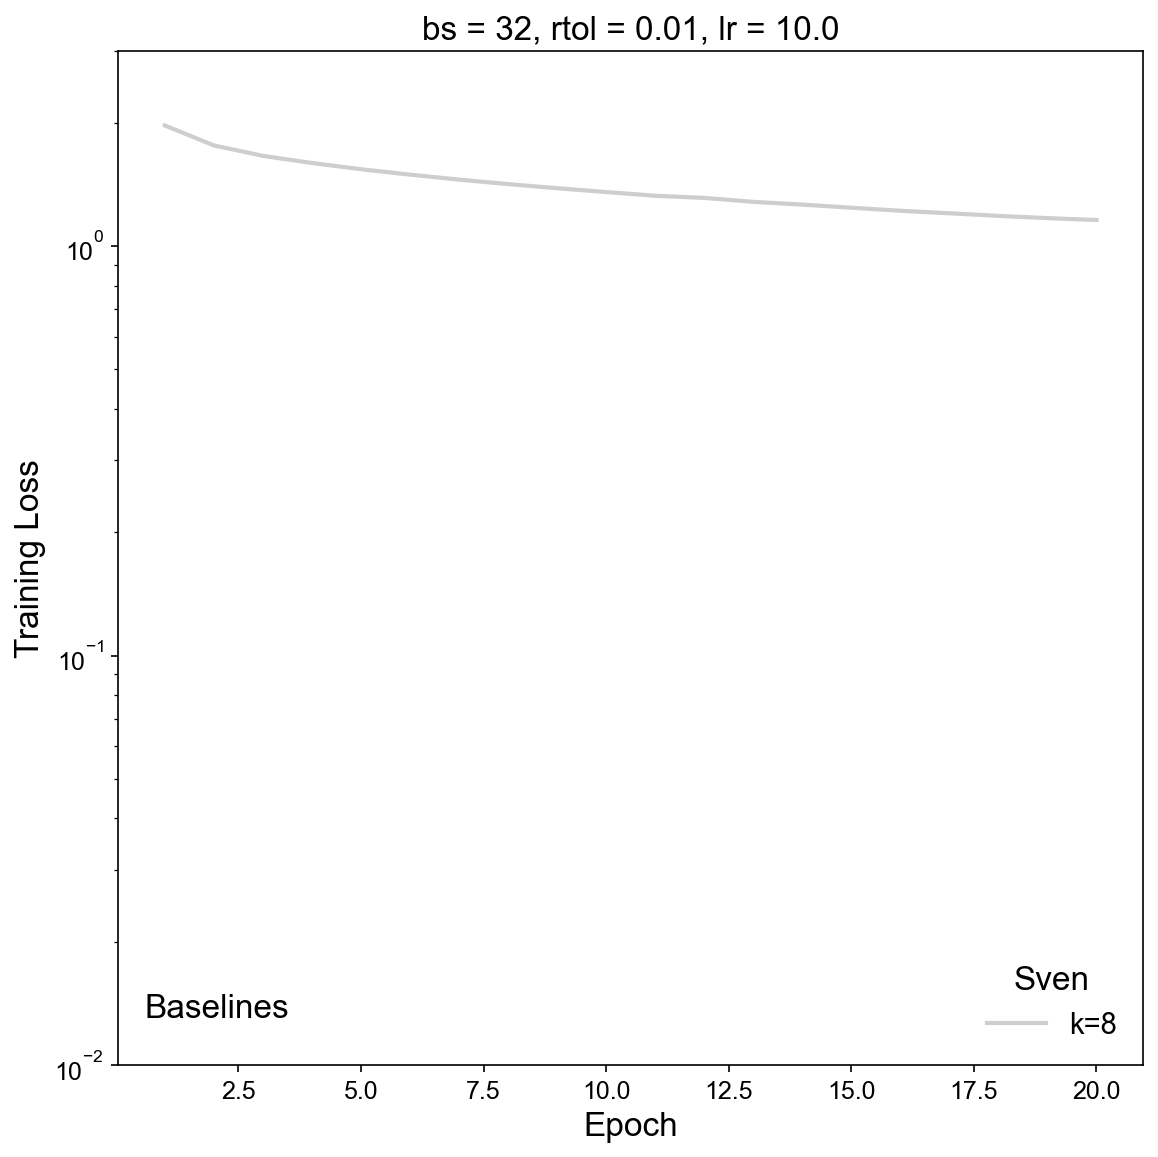

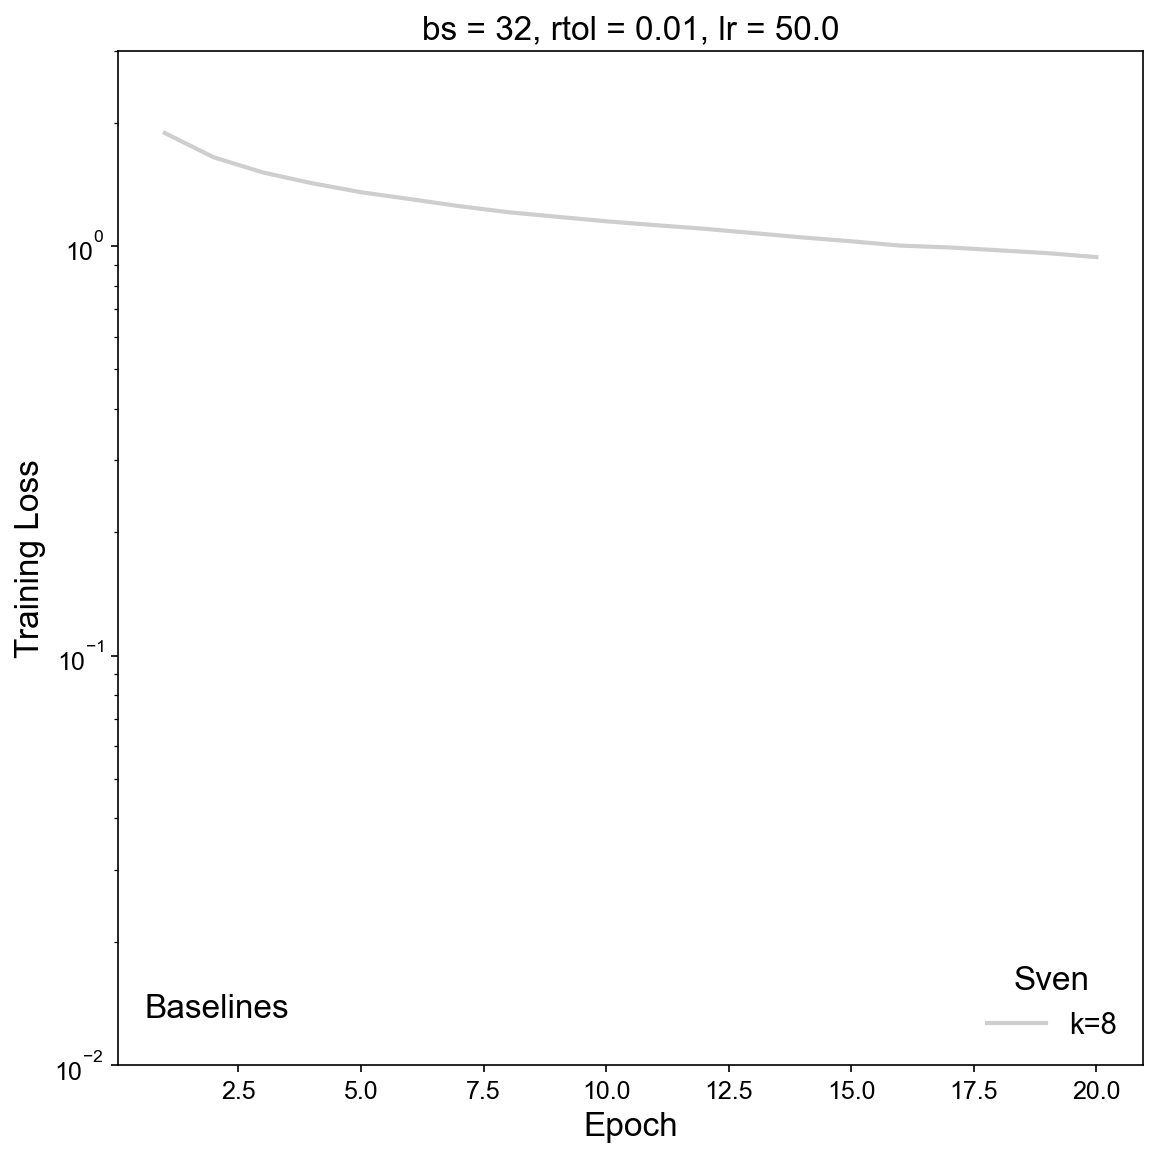

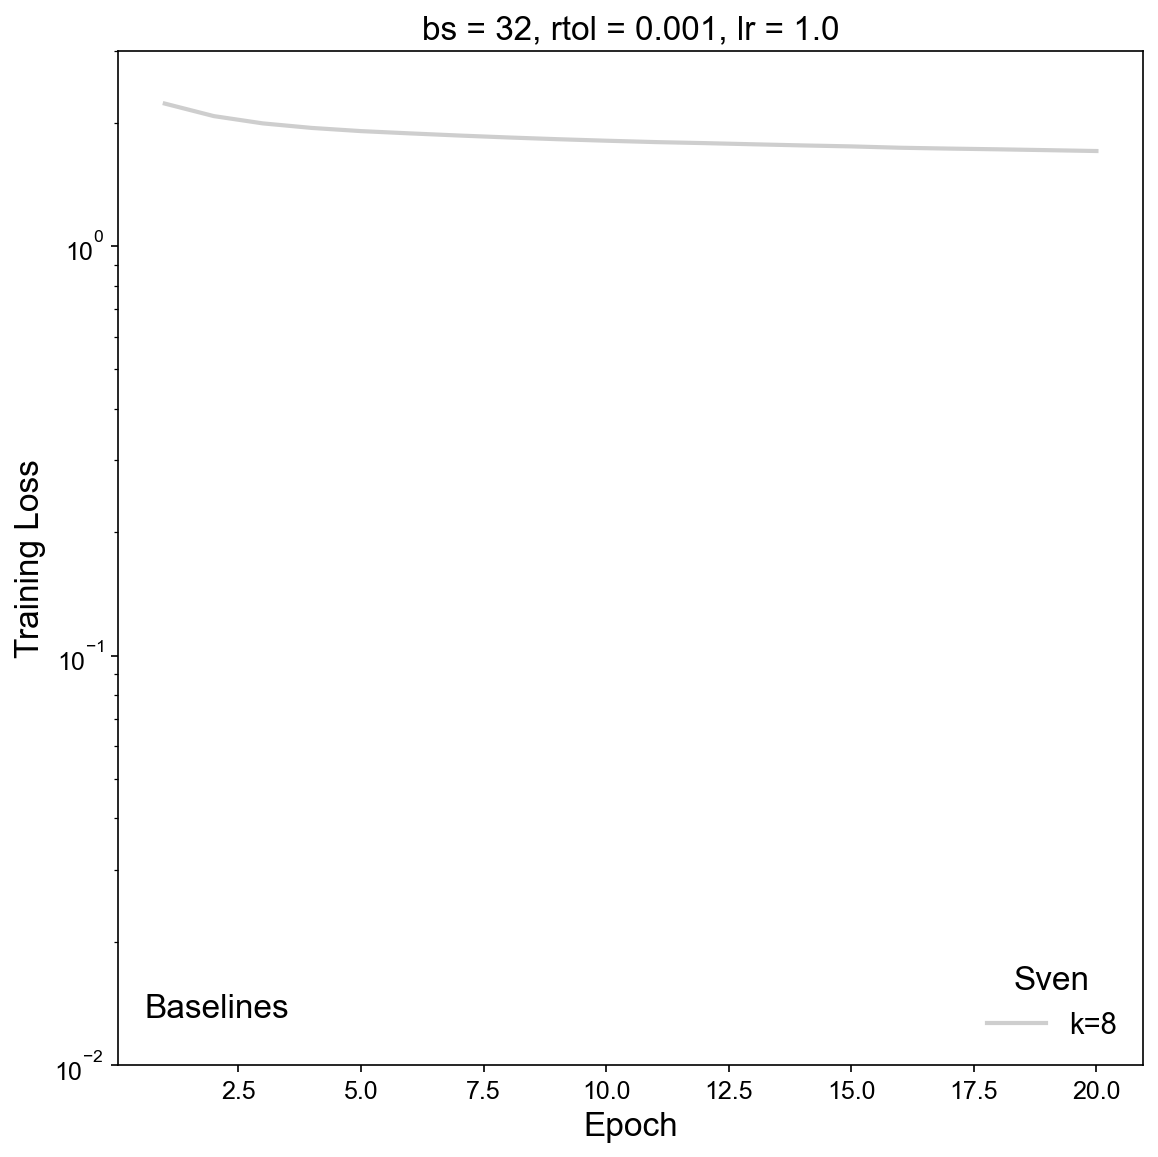

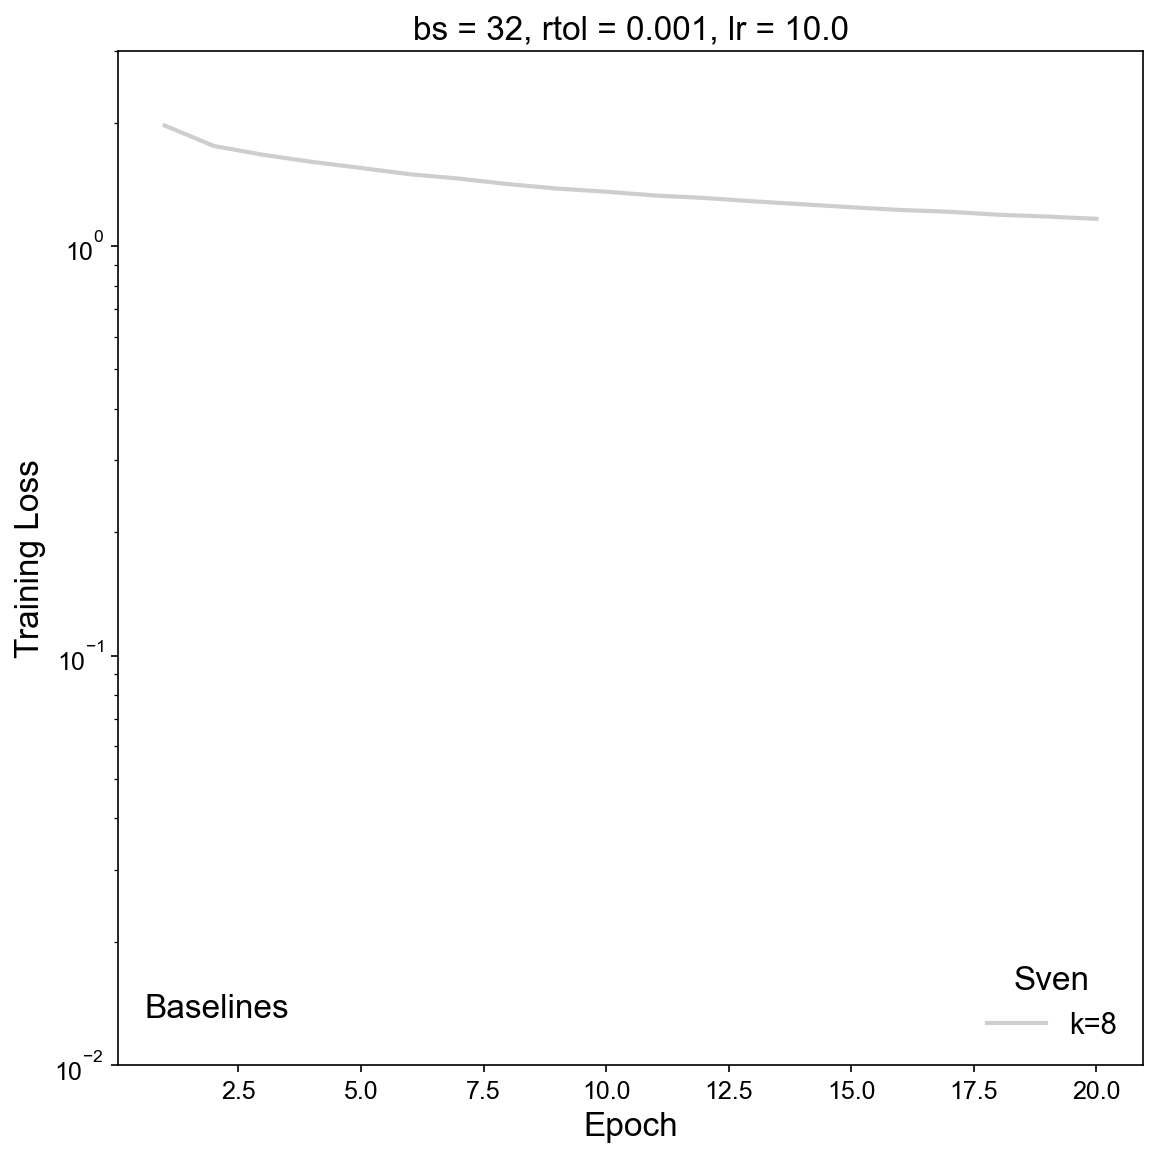

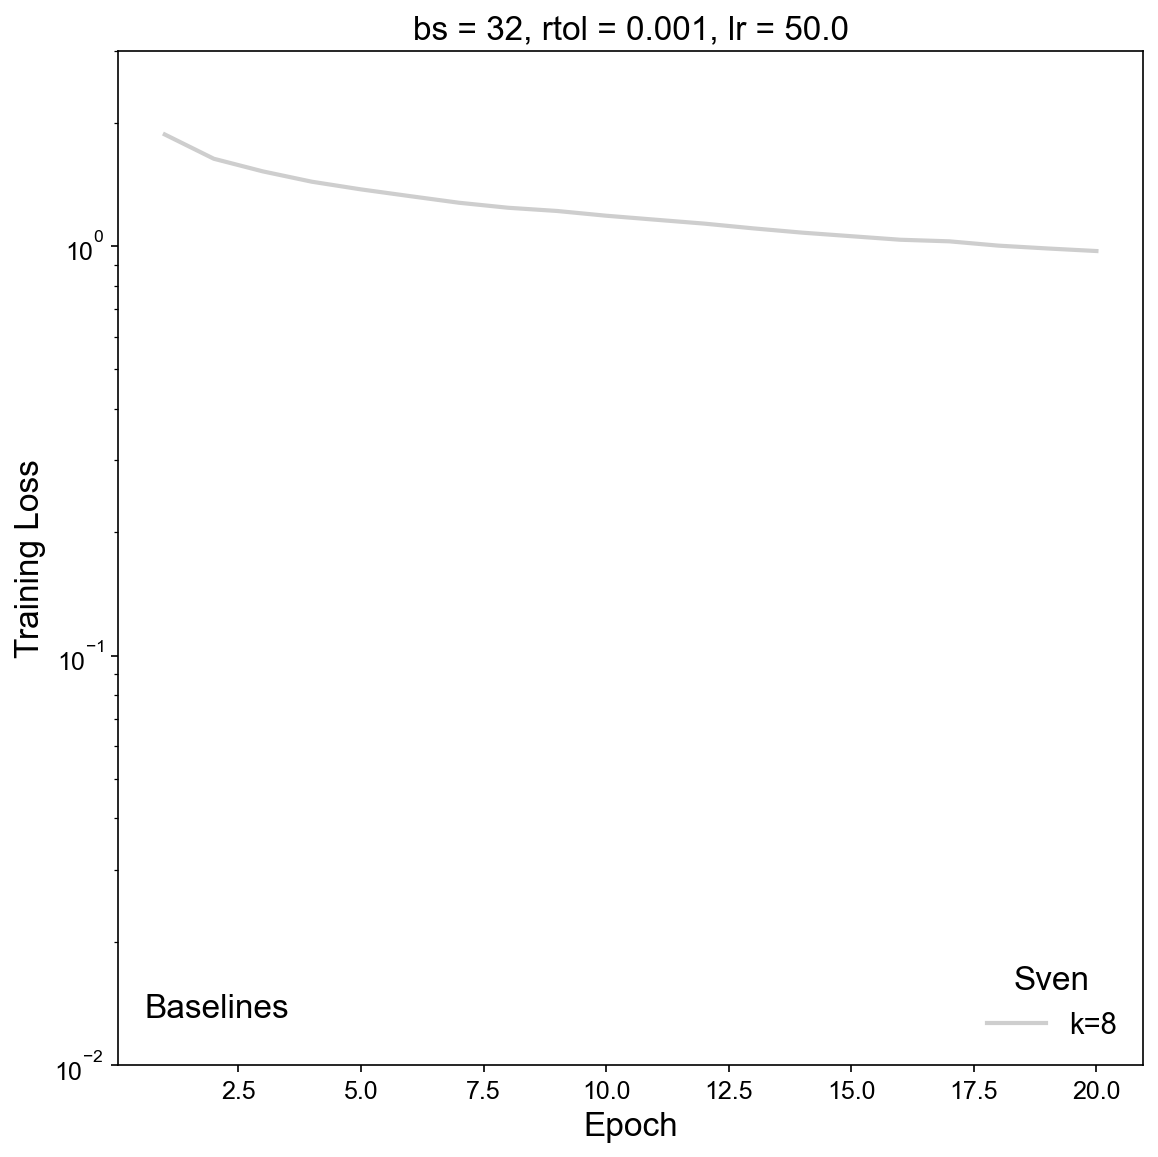

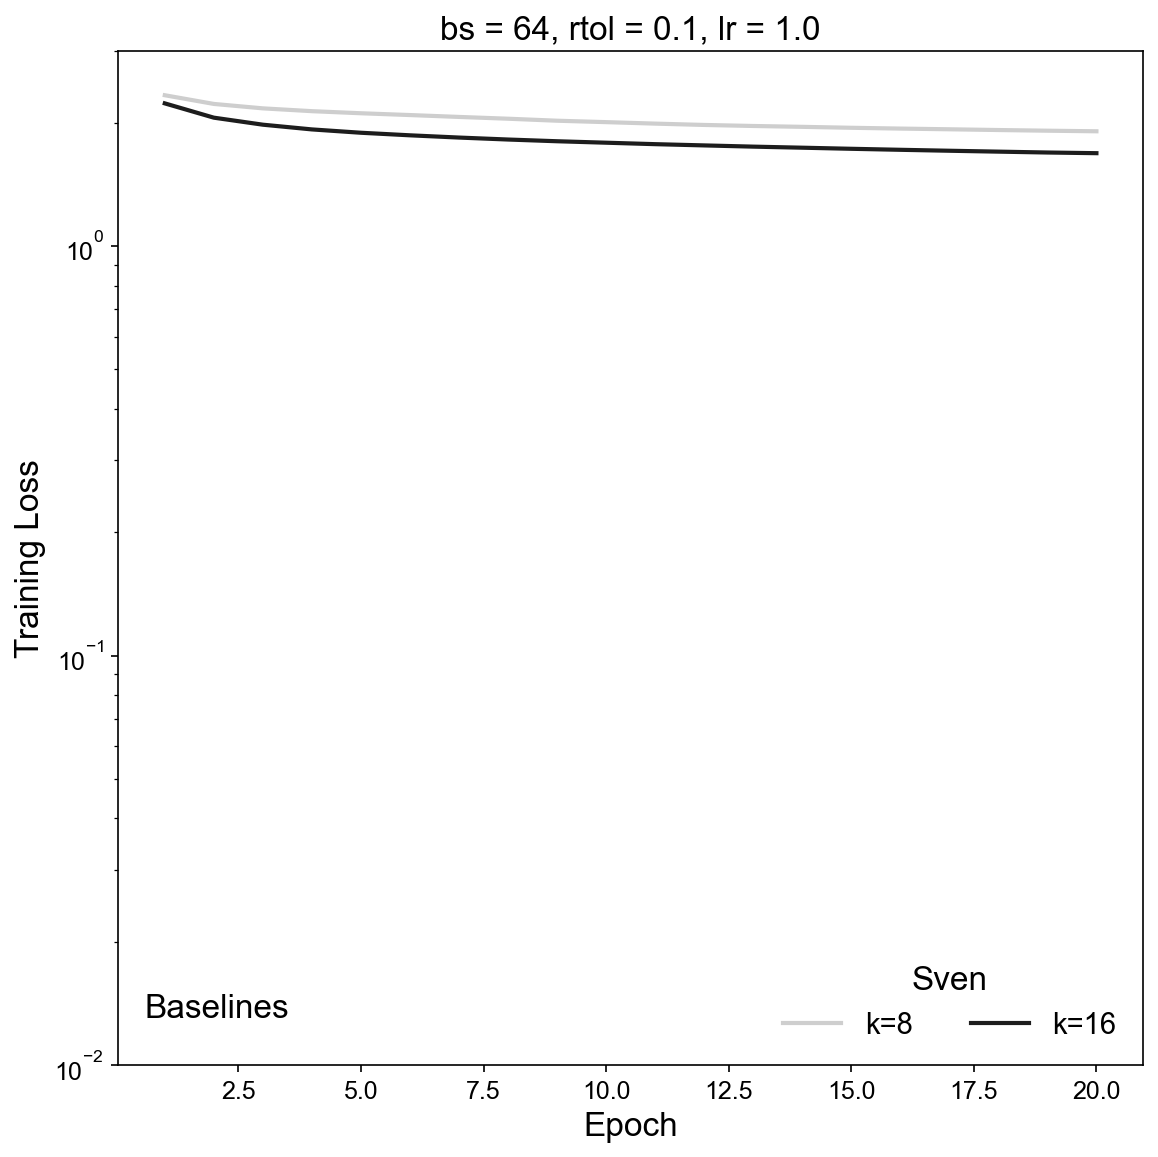

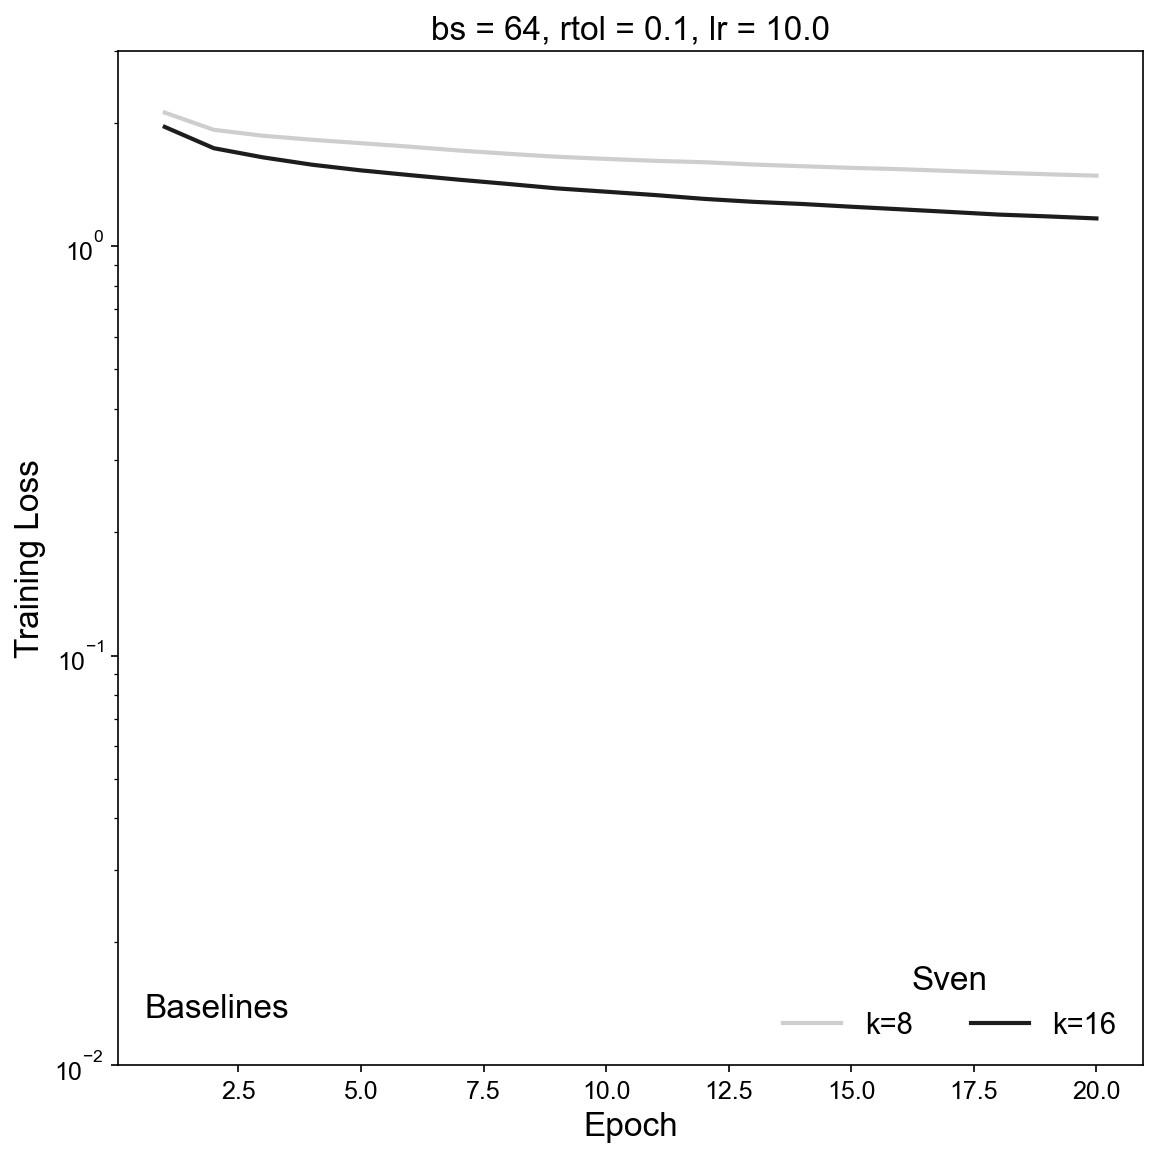

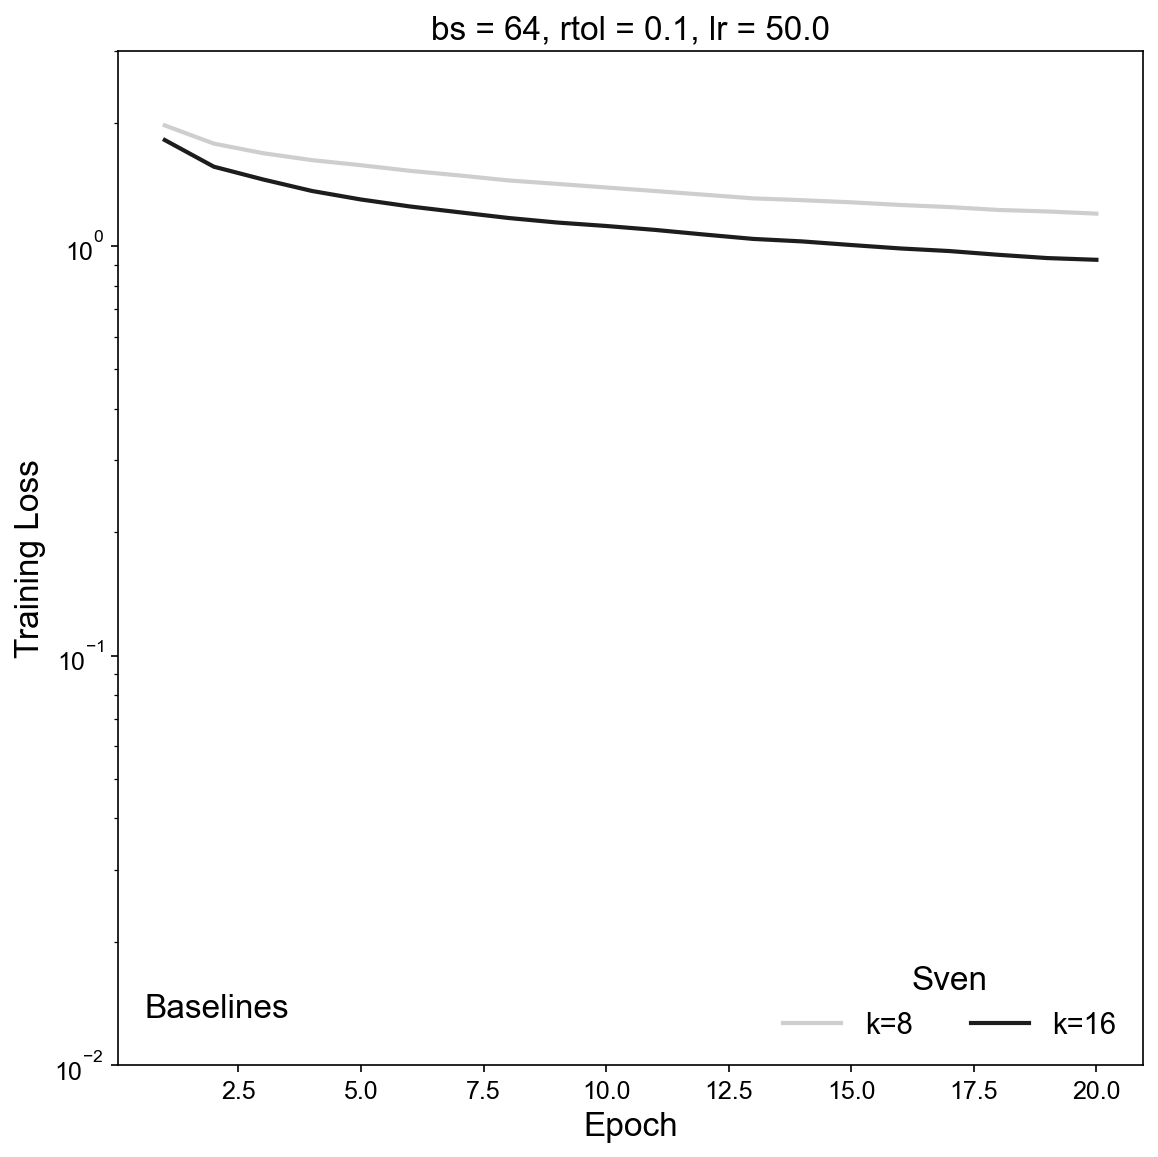

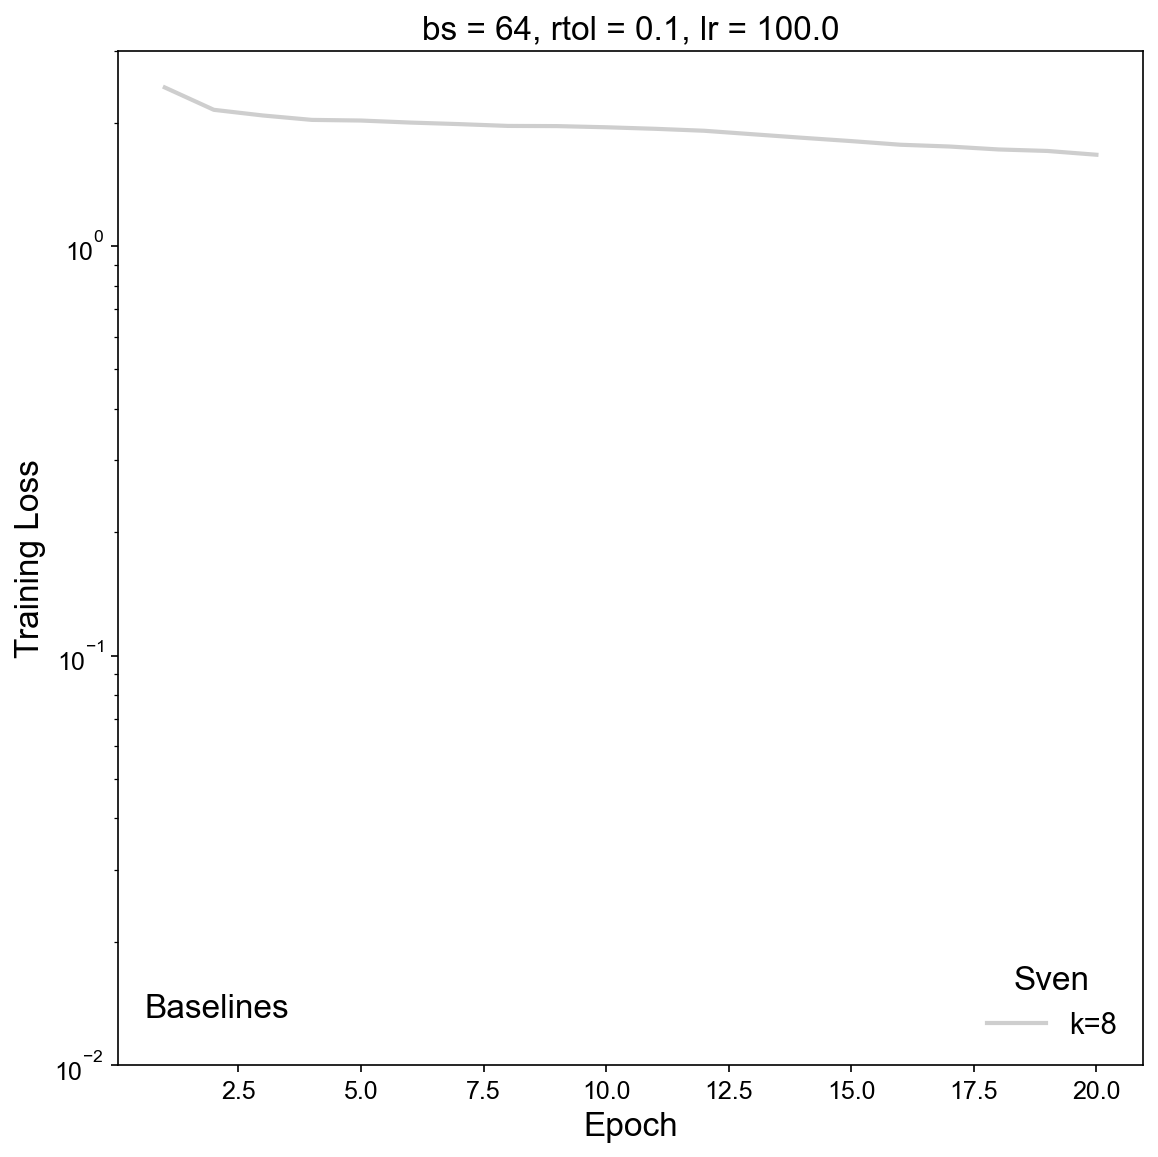

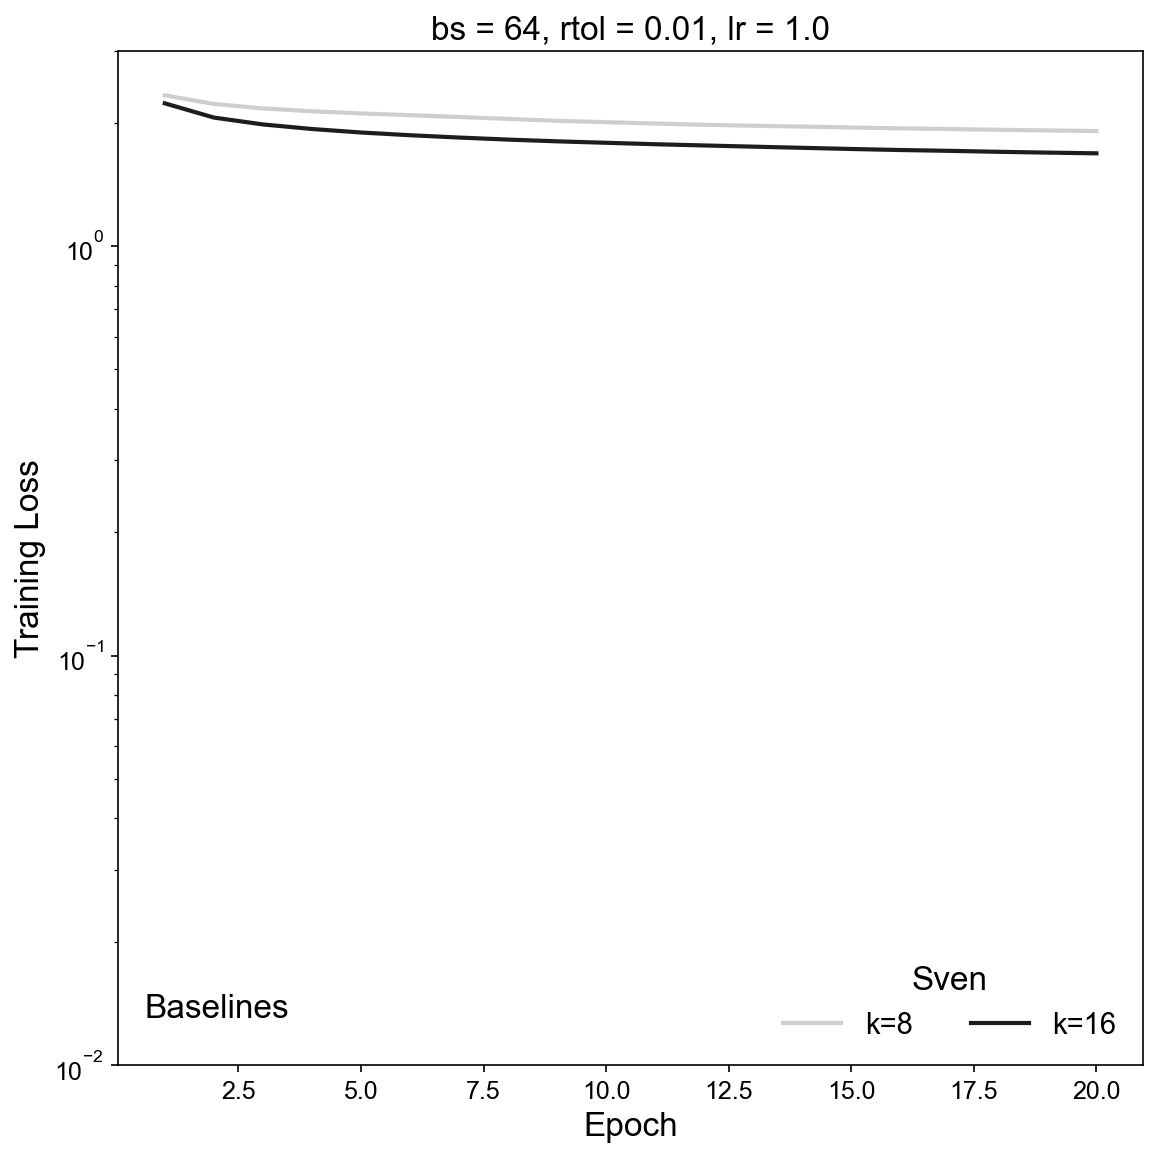

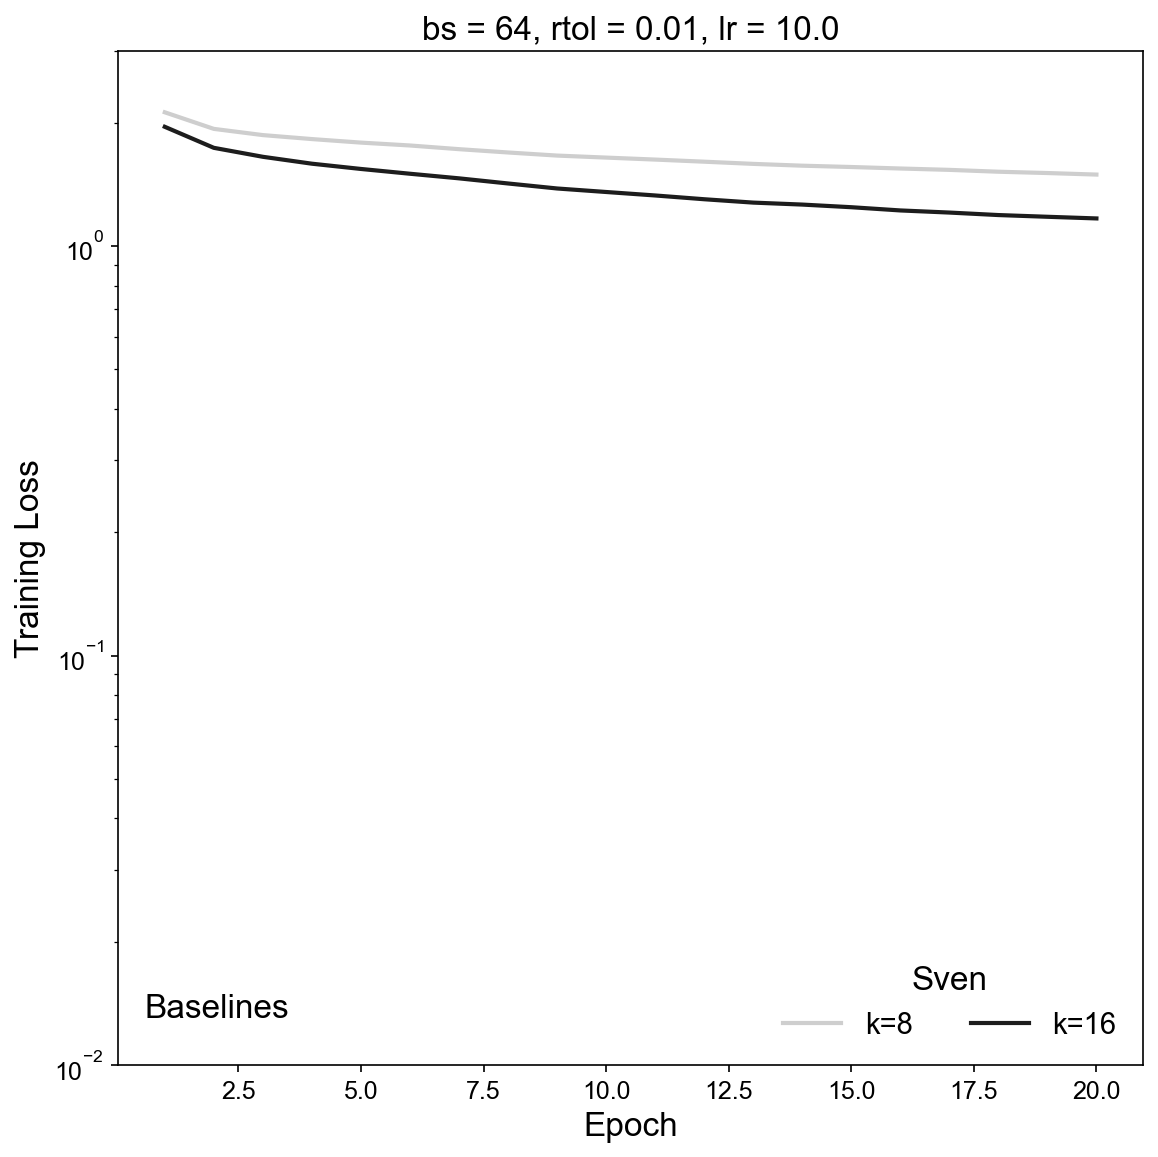

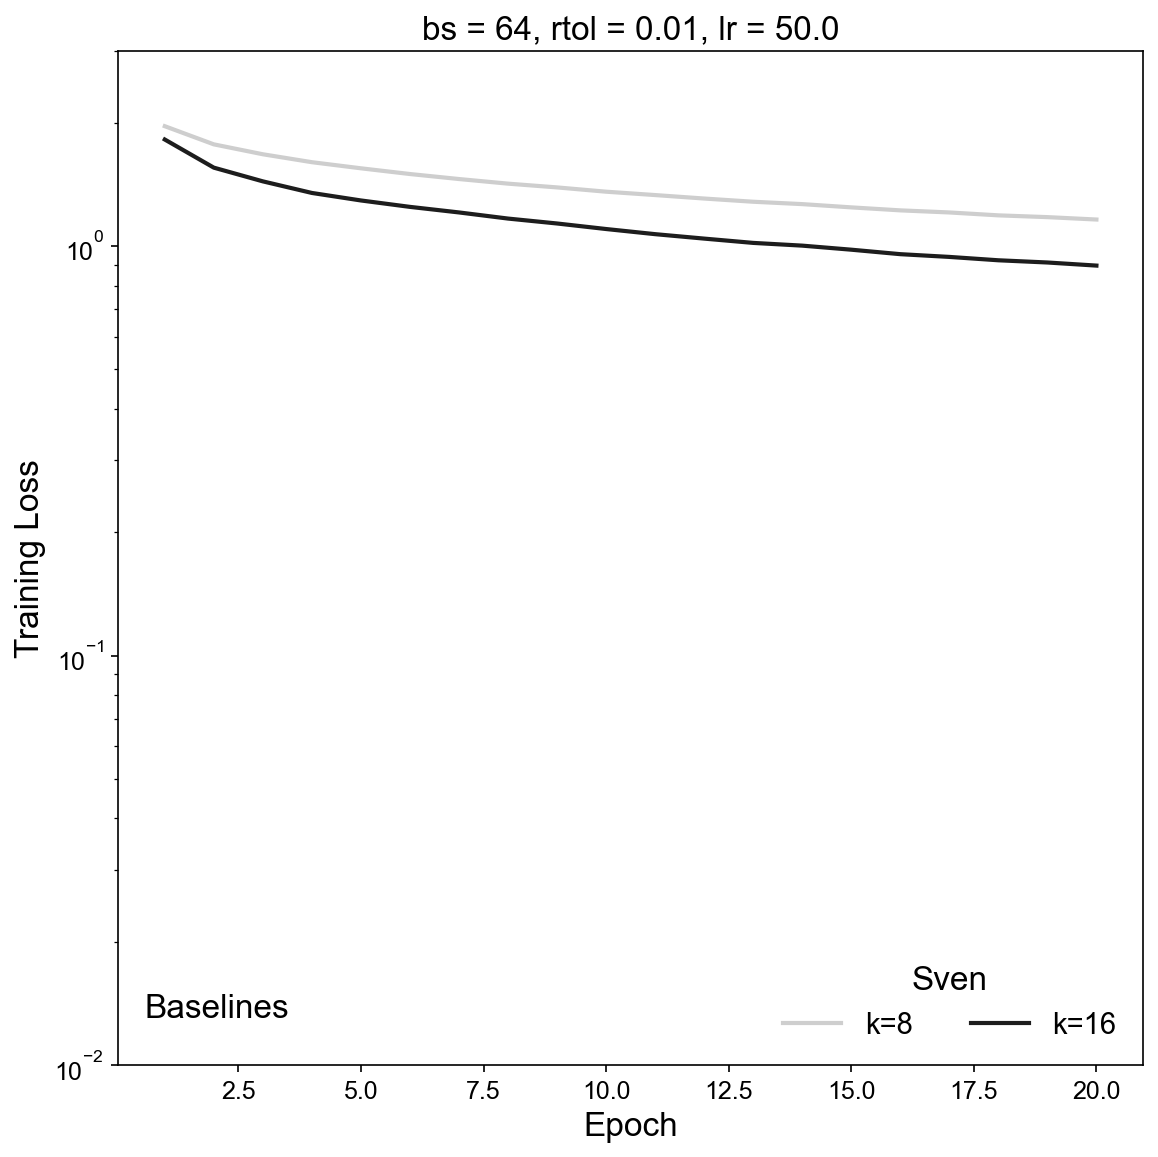

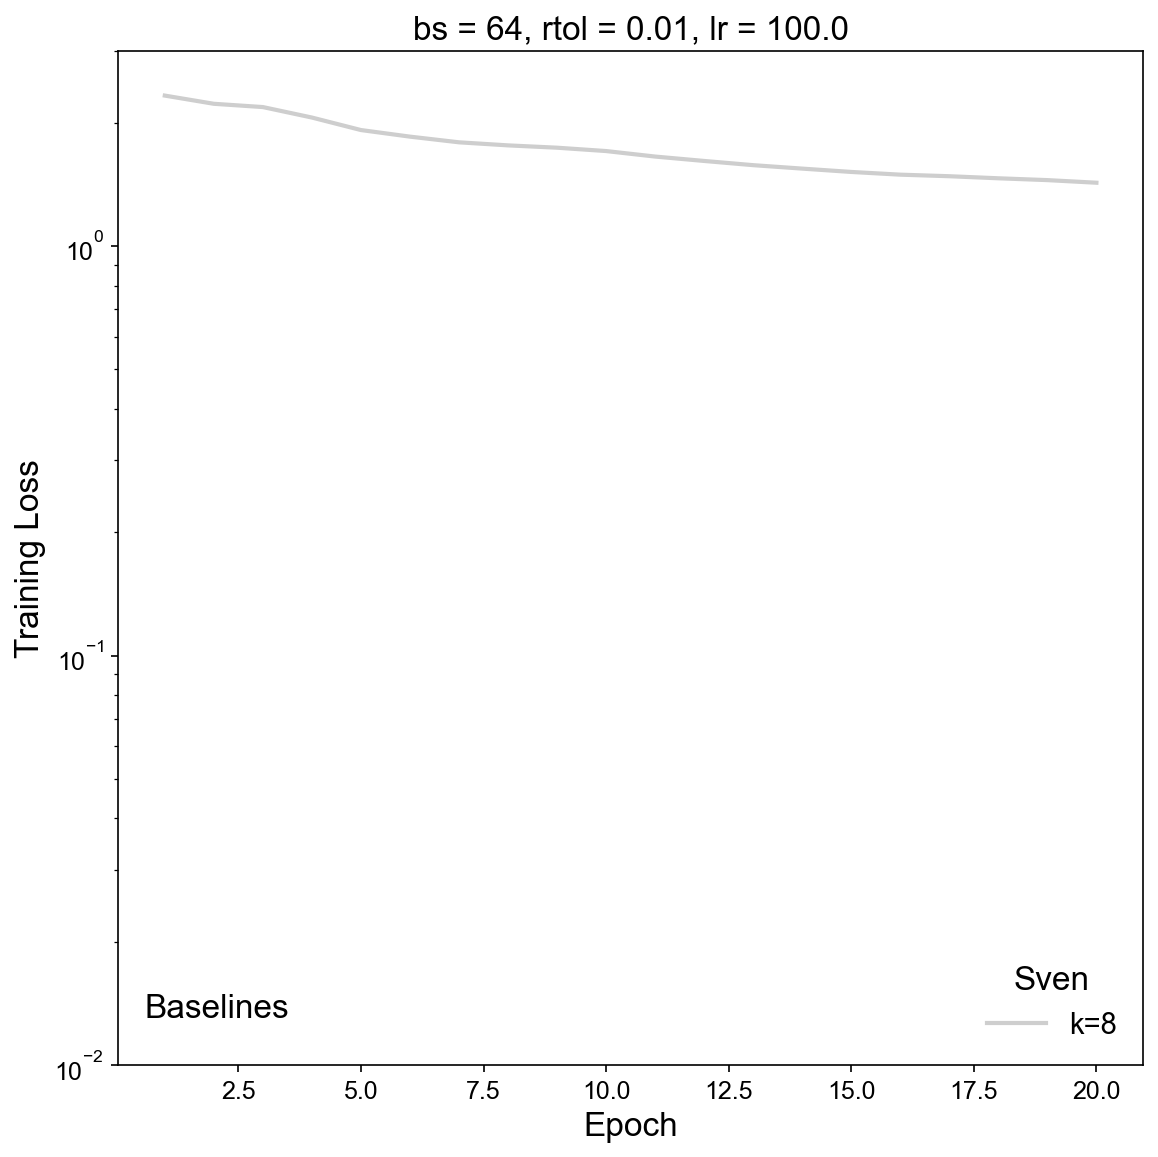

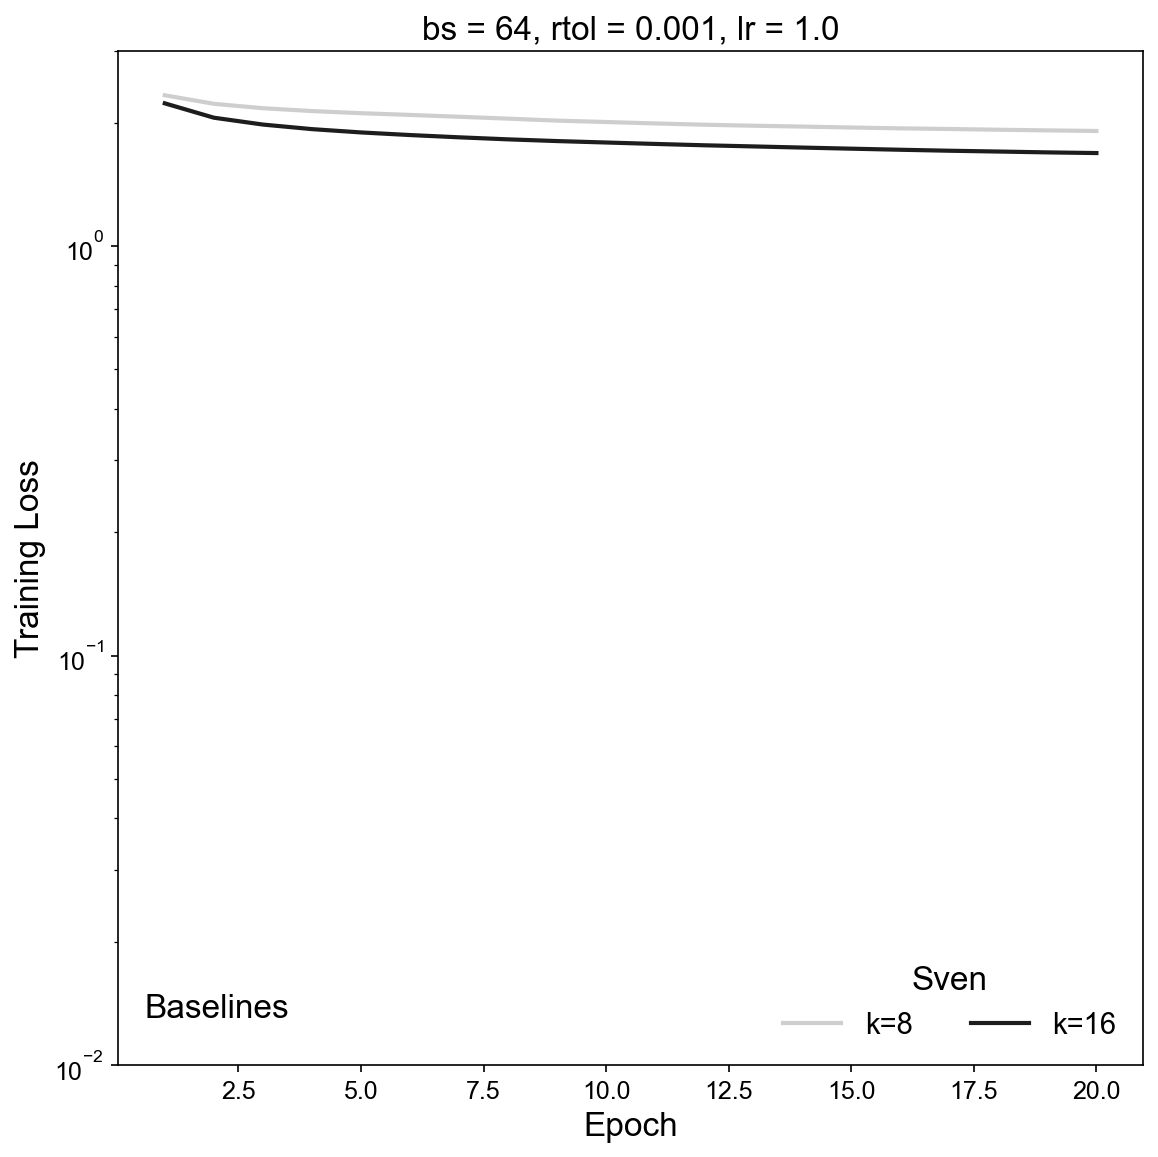

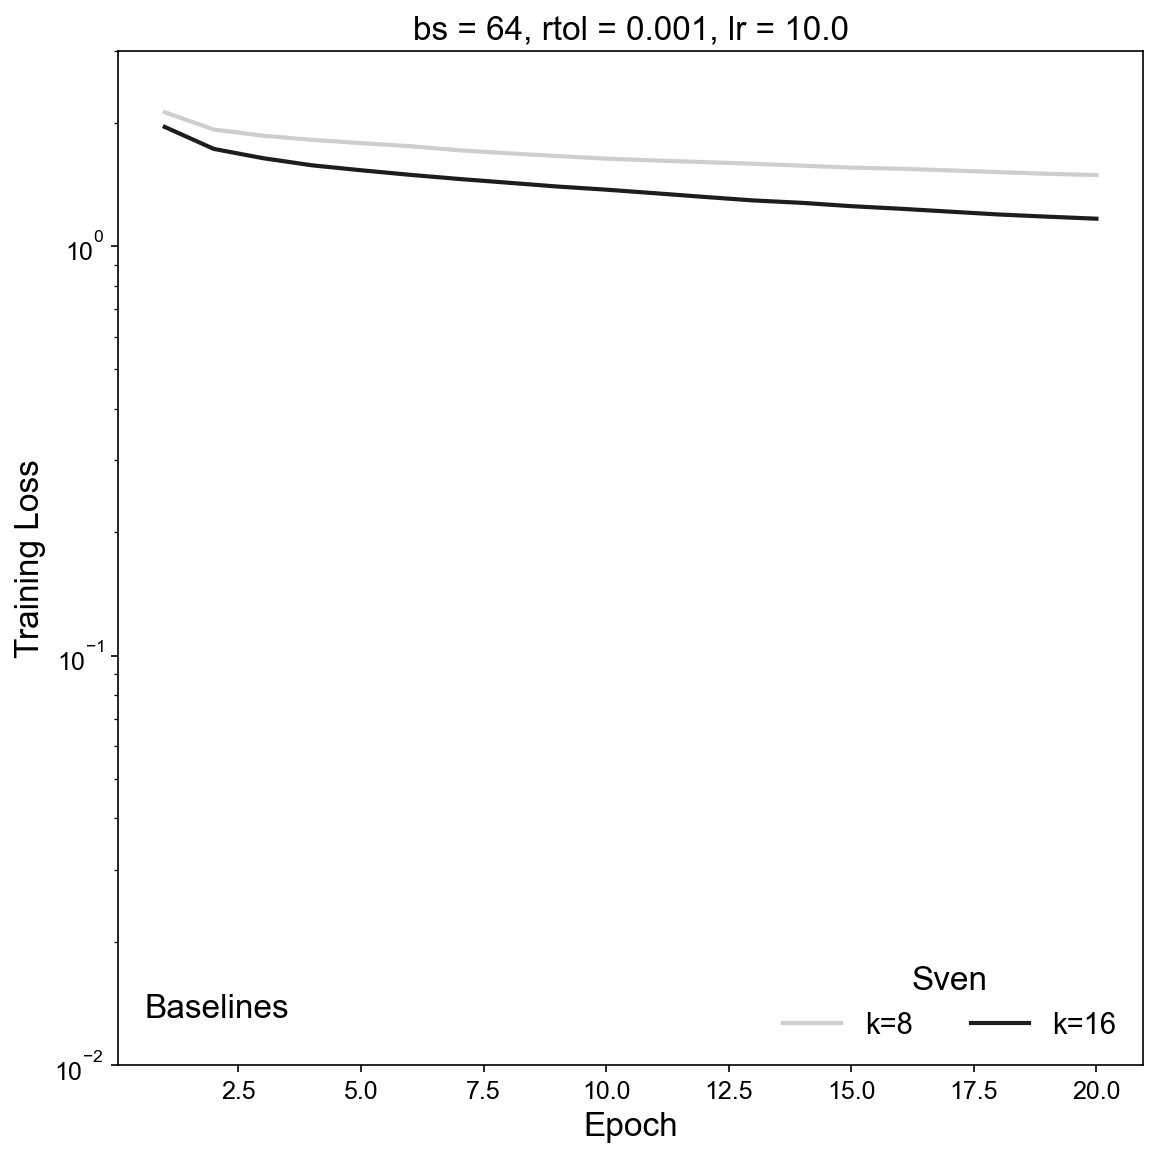

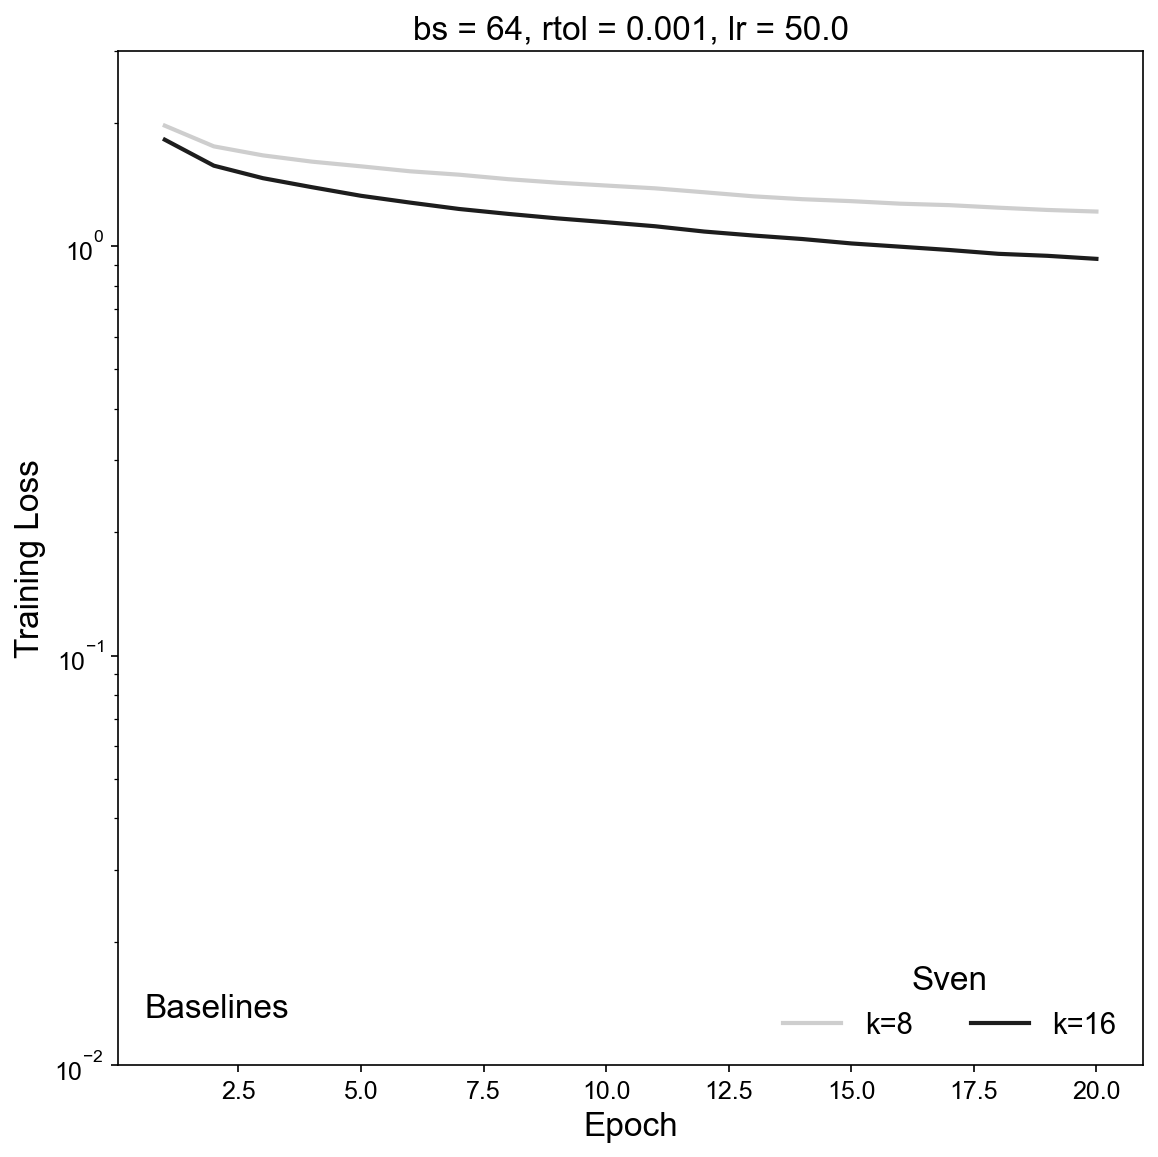

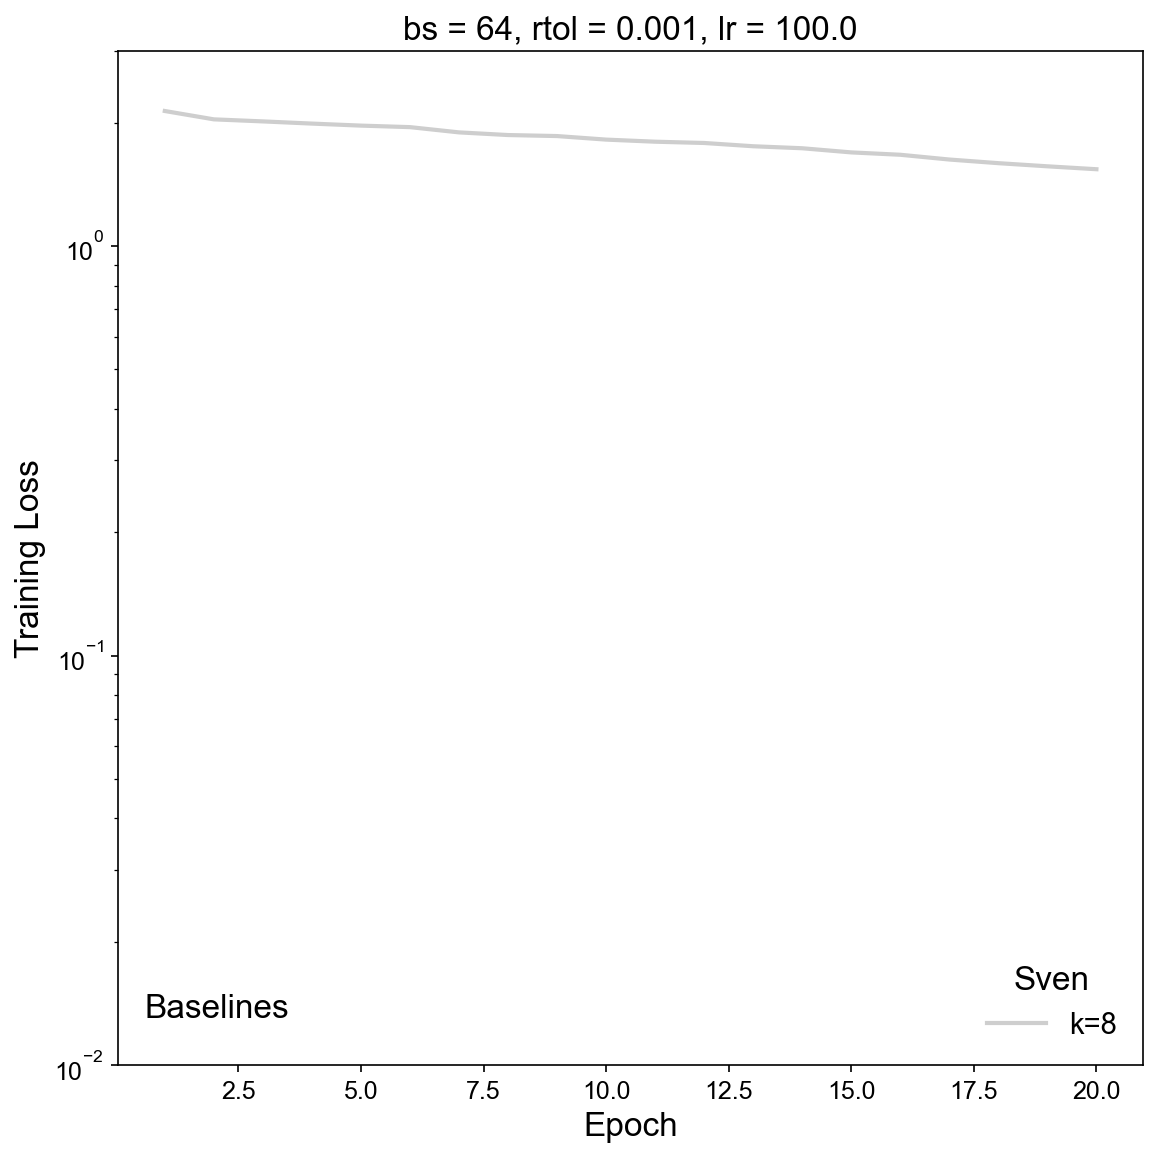

In [7]:
for BS in batch_sizes:
    for RTOL in [1e-1,1e-2,1e-3]:
        for LR in svd_lrs:
            epochs = np.arange(1,21)
            epochs_val = np.arange(21)

            df_svd_sel = df_svd[(df_svd['batch_size'] == BS) & (df_svd['rtol'] == RTOL) & (df_svd['lr'] == LR)]
            avail_k = sorted(df_svd_sel['k'].dropna().unique().tolist())

            if len(df_svd_sel) == 0:
                continue
            fig, ax = plt.subplots(figsize=(8, 8))
            legend_entries = []

            cmaps = plt.get_cmap('Greys')
            grays = [cmaps(i) for i in np.linspace(0.3, 0.9, len(avail_k))]
            for kval in avail_k:
                df_svd_k = df_svd_sel[df_svd_sel['k'] == kval].iloc[0]
                if len(df_svd_k) == 0:
                    continue

                train_losses = get_loss_curve(df_svd_k, 'train')
                val_losses = get_loss_curve(df_svd_k, 'val')

                legend_entries.append(Line2D([],[],label=f"k={int(kval)}",color=grays[avail_k.index(kval)],lw=2))
                ax.plot(epochs, train_losses, color=grays[avail_k.index(kval)], lw=2, linestyle='-')
                #ax.plot(epochs_val, val_losses, color=grays[avail_k.index(kval)], lw=2,linestyle='--')
            
            legend_entries_standard = []
            for iopt, opt in enumerate(optimizers_baseline):
                df_base_sel = df_baseline[(df_baseline['batch_size'] == BS) & (df_baseline['optimizer'] == opt)]
                if len(df_base_sel) == 0:
                    continue
                df_base = df_base_sel.iloc[0]
                train_losses = get_loss_curve(df_base, 'train')
                val_losses = get_loss_curve(df_base, 'val')
                legend_entries_standard.append(Line2D([],[],label=f"{opt}",color=f"C{iopt}",lw=2))
                ax.plot(epochs, train_losses, f'C{iopt}-', lw=2)
                #ax.plot(epochs_val, val_losses, f'C{iopt}--', lw=2)

            ax.set_xlabel('Epoch')
            ax.set_ylabel('Training Loss')
            ax.set_title(f"bs = {BS}, rtol = {RTOL}, lr = {LR}")
            ax.set_yscale('log')
            ax.set_ylim(1e-2,3)

            leg1 = ax.legend(handles=legend_entries, loc='lower right',ncol=2,title='Sven')
            ax.add_artist(leg1)

            leg2 = ax.legend(handles=legend_entries_standard, loc='lower left',title='Baselines')

            plt.tight_layout()
            #plt.savefig(PLOT_DIR / f'train_loss_kOverlay_bs{BS}_rtol{RTOL}_lr{LR}_withRmsProp.pdf')
            #plt.close()

### val loss

In [ ]:
for BS in batch_sizes:
    for RTOL in [1e-1,1e-2,1e-3]:
        for LR in svd_lrs:
            epochs = np.arange(1,21)
            epochs_val = np.arange(21)

            df_svd_sel = df_svd[(df_svd['batch_size'] == BS) & (df_svd['rtol'] == RTOL) & (df_svd['lr'] == LR)]
            avail_k = sorted(df_svd_sel['k'].dropna().unique().tolist())

            if len(df_svd_sel) == 0:
                continue
            fig, ax = plt.subplots(figsize=(8, 8))
            legend_entries = []

            cmaps = plt.get_cmap('Greys')
            grays = [cmaps(i) for i in np.linspace(0.3, 0.9, len(avail_k))]
            for kval in avail_k:
                df_svd_k = df_svd_sel[df_svd_sel['k'] == kval].iloc[0]
                if len(df_svd_k) == 0:
                    continue

                val_losses = get_loss_curve(df_svd_k, 'val')

                legend_entries.append(Line2D([],[],label=f"k={int(kval)}",color=grays[avail_k.index(kval)],lw=2))
                ax.plot(epochs_val, val_losses, color=grays[avail_k.index(kval)], lw=2, linestyle='-')
                #ax.plot(epochs_val, val_losses, color=grays[avail_k.index(kval)], lw=2,linestyle='--')
            
            legend_entries_standard = []
            for iopt, opt in enumerate(optimizers_baseline):
                df_base_sel = df_baseline[(df_baseline['batch_size'] == BS) & (df_baseline['optimizer'] == opt)]
                if len(df_base_sel) == 0:
                    continue
                df_base = df_base_sel.iloc[0]
                val_losses = get_loss_curve(df_base, 'val')
                legend_entries_standard.append(Line2D([],[],label=f"{opt}",color=f"C{iopt}",lw=2))
                ax.plot(epochs_val, val_losses, f'C{iopt}-', lw=2)
                #ax.plot(epochs_val, val_losses, f'C{iopt}--', lw=2)

            ax.set_xlabel('Epoch')
            ax.set_ylabel('Validation Loss')
            ax.set_title(f"bs = {BS}, rtol = {RTOL}, lr = {LR}")
            ax.set_yscale('log')
            ax.set_ylim(1e-2,3)

            leg1 = ax.legend(handles=legend_entries, loc='lower right',ncol=2,title='Sven')
            ax.add_artist(leg1)

            leg2 = ax.legend(handles=legend_entries_standard, loc='lower left',title='Baselines')

            plt.tight_layout()
            plt.savefig(PLOT_DIR / f'val_loss_kOverlay_bs{BS}_rtol{RTOL}_lr{LR}_withRmsProp.pdf')
            plt.close()

## compare learning curves at different rtol, fix bs / k / lr

### train loss

In [ ]:
for BS in batch_sizes:
    for k in k_values:
        for LR in svd_lrs:
            epochs = np.arange(1,21)
            epochs_val = np.arange(21)

            df_svd_sel = df_svd[(df_svd['batch_size'] == BS) & (df_svd['k'] == k) & (df_svd['lr'] == LR)]
            avail_rtol = sorted(df_svd_sel['rtol'].dropna().unique().tolist())

            if len(df_svd_sel) == 0:
                continue
            fig, ax = plt.subplots(figsize=(8, 8))
            legend_entries = []

            cmaps = plt.get_cmap('Greys')
            grays = [cmaps(i) for i in np.linspace(0.3, 0.9, len(avail_rtol))]
            for rtol in avail_rtol:
                df_svd_k = df_svd_sel[df_svd_sel['rtol'] == rtol].iloc[0]
                if len(df_svd_k) == 0:
                    continue

                train_losses = get_loss_curve(df_svd_k, 'train')
                val_losses = get_loss_curve(df_svd_k, 'val')

                legend_entries.append(Line2D([],[],label=f"rtol={rtol}",color=grays[avail_rtol.index(rtol)],lw=2))
                ax.plot(epochs, train_losses, color=grays[avail_rtol.index(rtol)], lw=2, linestyle='-')
                #ax.plot(epochs_val, val_losses, color=grays[avail_rtol.index(rtol)], lw=2,linestyle='--')
            
            legend_entries_standard = []
            for iopt, opt in enumerate(optimizers_baseline):
                df_base_sel = df_baseline[(df_baseline['batch_size'] == BS) & (df_baseline['optimizer'] == opt)]
                if len(df_base_sel) == 0:
                    continue
                df_base = df_base_sel.iloc[0]
                train_losses = get_loss_curve(df_base, 'train')
                val_losses = get_loss_curve(df_base, 'val')
                legend_entries_standard.append(Line2D([],[],label=f"{opt}",color=f"C{iopt}",lw=2))
                ax.plot(epochs, train_losses, f'C{iopt}-', lw=2)
                #ax.plot(epochs_val, val_losses, f'C{iopt}--', lw=2)

            ax.set_xlabel('Epoch')
            ax.set_ylabel('Training Loss')
            ax.set_title(f"bs = {BS}, k = {k}, lr = {LR}")
            ax.set_yscale('log')
            ax.set_ylim(1e-2,3)

            leg1 = ax.legend(handles=legend_entries, loc='lower right',ncol=2,title='Sven')
            ax.add_artist(leg1)

            leg2 = ax.legend(handles=legend_entries_standard, loc='lower left',title='Baselines')

            plt.tight_layout()
            plt.savefig(PLOT_DIR / f'train_loss_rtolOverlay_bs{BS}_k{k}_lr{LR}_withRmsProp.pdf')
            plt.close()

### val loss

In [ ]:
for BS in batch_sizes:
    for k in k_values:
        for LR in svd_lrs:
            epochs = np.arange(1,21)
            epochs_val = np.arange(21)

            df_svd_sel = df_svd[(df_svd['batch_size'] == BS) & (df_svd['k'] == k) & (df_svd['lr'] == LR)]
            avail_rtol = sorted(df_svd_sel['rtol'].dropna().unique().tolist())

            if len(df_svd_sel) == 0:
                continue
            fig, ax = plt.subplots(figsize=(8, 8))
            legend_entries = []

            cmaps = plt.get_cmap('Greys')
            grays = [cmaps(i) for i in np.linspace(0.3, 0.9, len(avail_rtol))]
            for rtol in avail_rtol:
                df_svd_k = df_svd_sel[df_svd_sel['rtol'] == rtol].iloc[0]
                if len(df_svd_k) == 0:
                    continue

                val_losses = get_loss_curve(df_svd_k, 'val')

                legend_entries.append(Line2D([],[],label=f"rtol={rtol}",color=grays[avail_rtol.index(rtol)],lw=2))
                ax.plot(epochs_val, val_losses, color=grays[avail_rtol.index(rtol)], lw=2, linestyle='-')
                #ax.plot(epochs_val, val_losses, color=grays[avail_rtol.index(rtol)], lw=2,linestyle='--')
            
            legend_entries_standard = []
            for iopt, opt in enumerate(optimizers_baseline):
                df_base_sel = df_baseline[(df_baseline['batch_size'] == BS) & (df_baseline['optimizer'] == opt)]
                if len(df_base_sel) == 0:
                    continue
                df_base = df_base_sel.iloc[0]
                val_losses = get_loss_curve(df_base, 'val')
                legend_entries_standard.append(Line2D([],[],label=f"{opt}",color=f"C{iopt}",lw=2))
                ax.plot(epochs_val, val_losses, f'C{iopt}-', lw=2)
                #ax.plot(epochs_val, val_losses, f'C{iopt}--', lw=2)

            ax.set_xlabel('Epoch')
            ax.set_ylabel('Validation Loss')
            ax.set_title(f"bs = {BS}, k = {k}, lr = {LR}")
            ax.set_yscale('log')
            ax.set_ylim(1e-2,3)

            leg1 = ax.legend(handles=legend_entries, loc='lower right',ncol=2,title='Sven')
            ax.add_artist(leg1)

            leg2 = ax.legend(handles=legend_entries_standard, loc='lower left',title='Baselines')

            plt.tight_layout()
            plt.savefig(PLOT_DIR / f'val_loss_rtolOverlay_bs{BS}_k{k}_lr{LR}_withRmsProp.pdf')
            plt.close()